In [1]:
import networkx as nx
import torch
import json
from pathlib import Path
from torch.utils.data import Subset
from torchtext.vocab import build_vocab_from_iterator
from torch_geometric.utils.convert import from_networkx
from torch_geometric.data import Data, HeteroData
from networkx.drawing.nx_pydot import graphviz_layout, pydot_layout

from halide_gnn_cost_model.ast_parser import parse_ast, ASTFormatVisitor, ASTGraphVisitor
from halide_gnn_cost_model.schedule_parser import  parse_schedule, ScheduleFormatVisitor, ScheduleGraphVisitor

In [2]:
PIPELINES_DIR = Path("/lscratch/fzhou48/pipelines-32k")
PIPELINE_DIR = PIPELINES_DIR / "pipeline_1_0"

# Visualize a Pipeline DAG

In [3]:
# Load the pipeline DAG from a JSON file.
DAG_JSON_PATH = PIPELINE_DIR / "dag.json"
with open(DAG_JSON_PATH, "r") as f:
    dag_data = json.load(f)

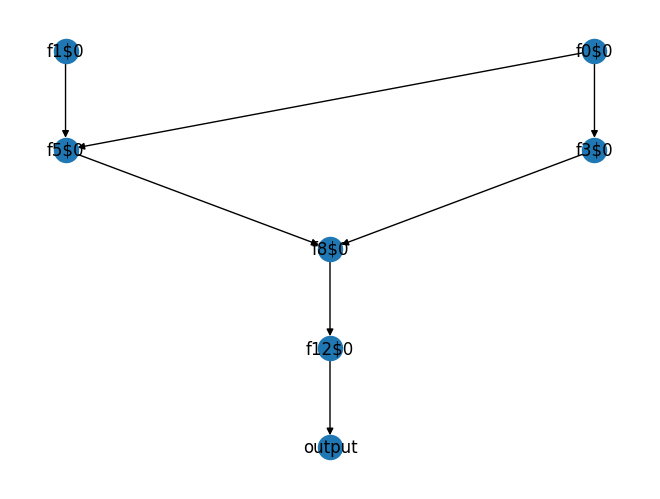

In [4]:
func_names = [func["name"] for func in dag_data]
dag = nx.DiGraph()
# Add function nodes.
for idx, func_name in enumerate(func_names):
    dag.add_node(idx, function=func_name)
# Add edges based on dependencies.
for idx, func in enumerate(dag_data):
    for dep in func["parents"]:
        dep_idx = func_names.index(dep)
        dag.add_edge(dep_idx, idx)
# Visualize the DAG.
labels = {n: dag.nodes[n]["function"] for n in dag.nodes()}
nx.draw(dag, labels=labels, pos=pydot_layout(dag, prog="dot"))

In [5]:
# Function name to DAG node ID mapping
func_name_to_id = {dag.nodes[n]["function"]: n for n in dag.nodes()}
func_name_to_id

{'output': 0,
 'f12$0': 1,
 'f8$0': 2,
 'f5$0': 3,
 'f1$0': 4,
 'f3$0': 5,
 'f0$0': 6}

# Visualize the AST

In [6]:
AST_PATH = PIPELINE_DIR / "ast.json"
with open(AST_PATH, "r") as f:
    ast_data = json.load(f)
ast_roots = parse_ast(ast_data)
for root in ast_roots:
    visitor = ASTFormatVisitor()
    root.accept(visitor)
    print(visitor.get_result())

output = (f12$0(v0, v1) / (v1 + 1))
f12$0 = (f8$0(v0, v1) / (8 + 1))
f8$0 = (f3$0(v0, v1) + f5$0(v0, v1))
f5$0 = (f1$0(v0, v1) / (f0$0(v0, v1) + 1))
f1$0 = (v1 + 1)
f3$0 = (f0$0(v0, v1) + f0$0(v0, v1))
f0$0 = (7 - 0)


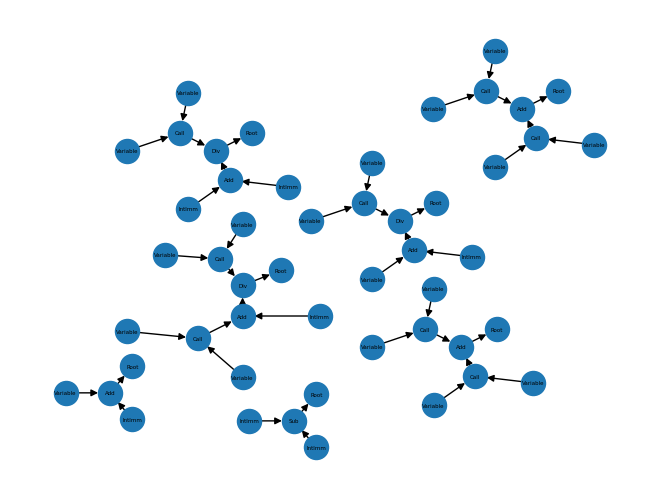

In [7]:
ast_graphs = []
for root in ast_roots:
    visitor = ASTGraphVisitor()
    root.accept(visitor)
    ast_graphs.append(visitor.get_graph())
ast_graph = nx.disjoint_union_all(ast_graphs)
labels = {n: ast_graph.nodes[n]["node_type"] for n in ast_graph.nodes()}
nx.draw(ast_graph, pos=graphviz_layout(ast_graph, prog="twopi"), labels=labels, font_size=4)

# Visualize the Schedule

In [8]:
SCHEDULE_PATH = PIPELINE_DIR / "schedule.json"
with open(SCHEDULE_PATH, "r") as f:
    schedule_data = json.load(f)
schedule_root = parse_schedule(schedule_data)
visitor = ScheduleFormatVisitor()
schedule_root.accept(visitor)
print(visitor.get_result())

for v0 [0:unknown] (serial)
  for v1 [0:unknown] (serial)
    compute(f0$0)
for v0.v0_in [0:15] (parallel)
  for v1 [0:unknown] (serial)
    for v0.v0_out [0:unknown] (serial)
      compute(f3$0)
for v1 [0:unknown] (parallel)
  for v0 [0:unknown] (serial)
    for v1.v1_in [0:3] (serial)
      compute(f1$0)
    compute(f5$0)
for v0 [0:unknown] (parallel)
  for v1.v1_in [0:15] (serial)
    for v1.v1_out [0:unknown] (serial)
      compute(f8$0)
store(f12$0)
  for v1 [0:unknown] (serial)
    for v0.v0_out [0:unknown] (serial)
      for v0.v0_in [0:7] (vectorized)
        compute(f12$0)
    for v0 [0:unknown] (serial)
      compute(output)



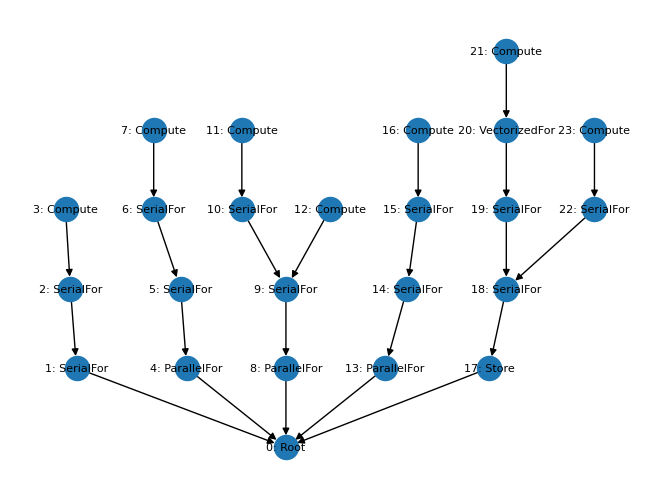

In [9]:
graph_visitor = ScheduleGraphVisitor()
schedule_root.accept(graph_visitor)
schedule_graph = graph_visitor.get_graph()
labels = {n: f"{n}: {schedule_graph.nodes[n]['node_type']}" for n in schedule_graph.nodes()}
nx.draw(schedule_graph, pos=graphviz_layout(schedule_graph, prog="dot"), labels=labels, font_size=8)

In [10]:
# Function to schedule loop level mapping
func_to_loop_levels = {}
for idx, loop_level in schedule_graph.nodes(data=True):
    if loop_level["node_type"] == "Compute" or loop_level["node_type"] == "Store":
        func_name = loop_level["func"]
        if func_name not in func_to_loop_levels:
            func_to_loop_levels[func_name] = []
        func_to_loop_levels[func_name].append(idx)
func_to_loop_levels

{'f0$0': [3],
 'f3$0': [7],
 'f1$0': [11],
 'f5$0': [12],
 'f8$0': [16],
 'f12$0': [17, 21],
 'output': [23]}

# Benchmark Result

In [11]:
# Pipeline Benchmark Result
BENCHMARK_PATH = PIPELINE_DIR / "benchmark.json"
with open(BENCHMARK_PATH, "r") as f:
    benchmark_data = json.load(f)
y = torch.tensor([benchmark["real_time"] for benchmark in benchmark_data["benchmarks"]], dtype=torch.float)
y

tensor([  1.6754,   5.9787,  24.9818,  96.6424, 514.3264])

# Compose Heterogeneous Graph

In [12]:
data = HeteroData()
# Add DAG nodes
data["function"].x = torch.ones((dag.number_of_nodes(), 1), dtype=torch.float)
data["function", "called_by", "function"].edge_index = torch.tensor(list(dag.edges)).T.contiguous()

# Add AST nodes
node_types = [ast_node["node_type"] for _, ast_node in ast_graph.nodes(data=True)]
ast_vocab = build_vocab_from_iterator([node_types])
node_tokens = [ast_vocab[node_type] for node_type in node_types]
data["ast_node"].x = torch.tensor(node_tokens, dtype=torch.int).unsqueeze(-1)
data["ast_node", "child_of", "ast_node"].edge_index = torch.tensor(list(ast_graph.edges)).T.contiguous()

# Connect AST to corresponding function nodes
ast_to_func_edges = []
for ast_node_idx, ast_node in ast_graph.nodes(data=True):
    if ast_node["node_type"] != "Root":
        continue
    func_name = ast_node["function"]
    if func_name in func_name_to_id:
        func_idx = func_name_to_id[func_name]
        ast_to_func_edges.append((ast_node_idx, func_idx))
data["ast_node", "is_expr_of", "function"].edge_index = torch.tensor(ast_to_func_edges).T.contiguous()
data.y = y

# Add Schedule nodes
node_types = [sched_node["node_type"] for _, sched_node in schedule_graph.nodes(data=True)]
sched_vocab = build_vocab_from_iterator([node_types])
node_tokens = [sched_vocab[node_type] for node_type in node_types]

data["loop_level"].x = torch.tensor(node_tokens, dtype=torch.int).unsqueeze(-1)
data["loop_level", "child_of", "loop_level"].edge_index = torch.tensor(list(schedule_graph.edges)).T.contiguous()

# Connect function to corresponding schedule nodes
func_to_sched_edges = []
for func_idx, func_node in dag.nodes(data=True):
    func_name = func_node["function"]
    if func_name in func_to_loop_levels:
        for sched_node_idx in func_to_loop_levels[func_name]:
            func_to_sched_edges.append((func_idx, sched_node_idx))
data["function", "schedule_at", "loop_level"].edge_index = torch.tensor(func_to_sched_edges).T.contiguous()

data

1lines [00:00, 3894.43lines/s]
1lines [00:00, 18157.16lines/s]


HeteroData(
  y=[5],
  function={ x=[7, 1] },
  ast_node={ x=[50, 1] },
  loop_level={ x=[24, 1] },
  (function, called_by, function)={ edge_index=[2, 7] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 43] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 7] },
  (loop_level, child_of, loop_level)={ edge_index=[2, 23] },
  (function, schedule_at, loop_level)={ edge_index=[2, 8] }
)

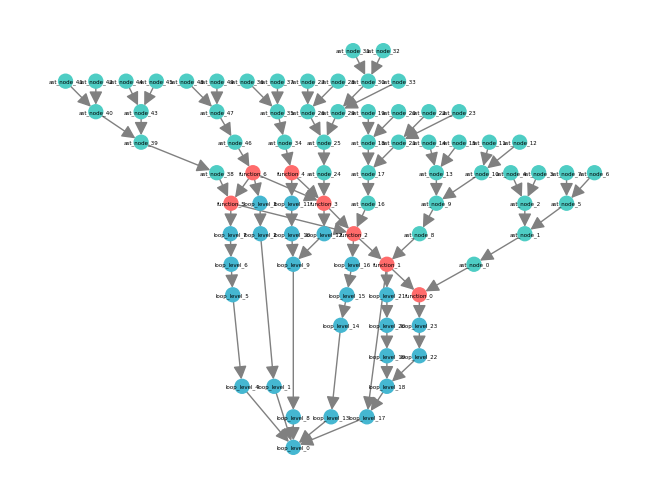

In [13]:
# Convert HeteroData to NetworkX DiGraph
G = nx.DiGraph()

# Add all node types
for node_type in data.node_types:
    num_nodes = data[node_type].x.shape[0]
    for i in range(num_nodes):
        G.add_node(f"{node_type}_{i}", node_type=node_type)

# Add all edge types
for edge_type in data.edge_types:
    src_type, rel_type, dst_type = edge_type
    edge_index = data[edge_type].edge_index
    for src_idx, dst_idx in edge_index.T:
        G.add_edge(f"{src_type}_{src_idx}", f"{dst_type}_{dst_idx}", relation=rel_type)

# Define color map for node types
color_map = {
    "function": "#FF6B6B",
    "ast_node": "#4ECDC4",
    "loop_level": "#45B7D1"
}

# Assign colors to nodes
node_colors = [color_map.get(G.nodes[node]["node_type"], "#95E1D3") for node in G.nodes()]

# Plot the graph
labels = {node: node for node in G.nodes()}
pos = graphviz_layout(G, prog="dot")
nx.draw(G, pos=pos, labels=labels, node_color=node_colors,
        with_labels=True, node_size=100, font_size=4, 
        edge_color="gray", arrowsize=20)

# Use Data Utils to Load Dataset

In [14]:
from halide_gnn_cost_model.data import load_pipeline, PipelineDataset

In [15]:
dataset = PipelineDataset(PIPELINES_DIR)
len(dataset)

1lines [00:00, 16980.99lines/s]
1lines [00:00, 28728.11lines/s]


32694

In [16]:
indicies = torch.randperm(len(dataset))
for idx, data in enumerate(Subset(dataset, indicies[:8])):
    print(f"Pipeline {idx} has {data['function'].x.shape[0]} functions.")

Pipeline 0 has 6 functions.
Pipeline 1 has 9 functions.
Pipeline 2 has 8 functions.
Pipeline 3 has 4 functions.
Pipeline 4 has 6 functions.
Pipeline 5 has 5 functions.
Pipeline 6 has 5 functions.
Pipeline 7 has 7 functions.
